<a href="https://colab.research.google.com/github/hdpark1208/StudyCode/blob/main/Algorithm/BJ/%EC%9D%B4%EC%A4%91%20%EC%9A%B0%EC%84%A0%EC%88%9C%EC%9C%84%20%ED%81%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 이중 우선순위 큐

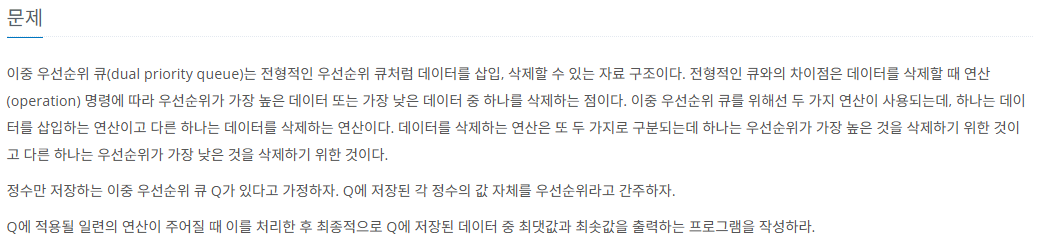

## 입력 출력 및 예제


* 입력

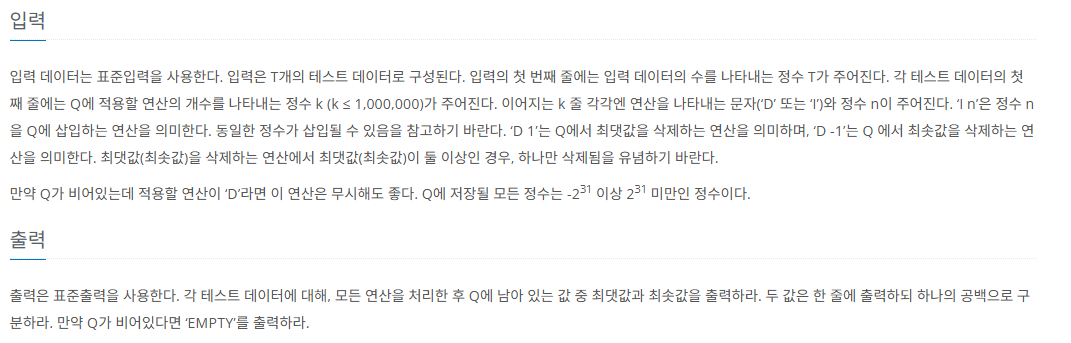

* 출력

* 예제

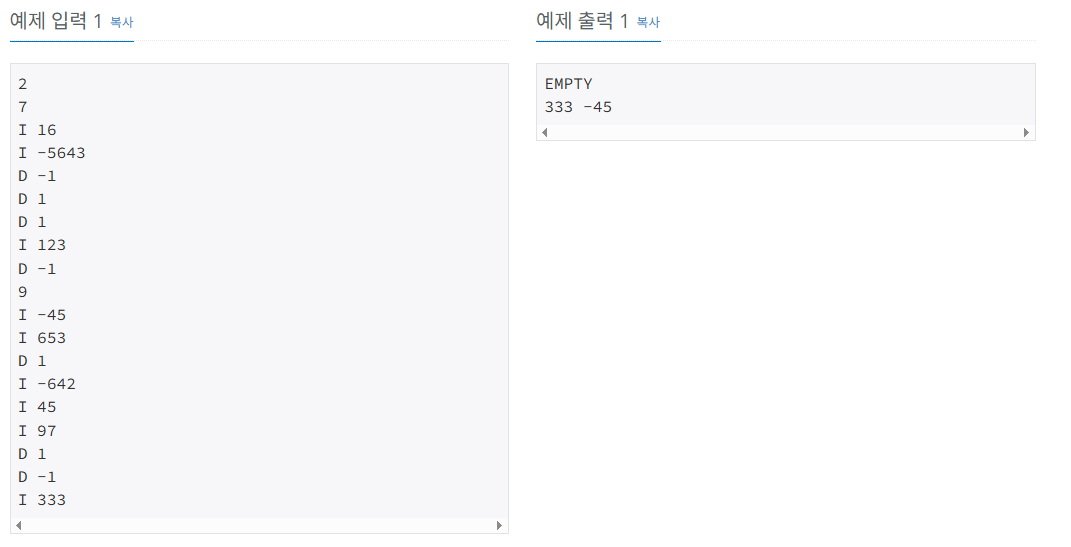

## 구상

* 최대힙, 최소힙 2개 관리
* 원소 관리 어떻게 ?

## 코드

In [ ]:
import sys
import heapq

input = sys.stdin.readline

T = int(input())

for _ in range(T):
    k = int(input())

    min_heap = []
    max_heap = []
    visited = [False] * k  # 각 삽입 연산의 생존 여부

    def clean_min():
        while min_heap and not visited[min_heap[0][1]]:
            heapq.heappop(min_heap)

    def clean_max():
        while max_heap and not visited[max_heap[0][1]]:
            heapq.heappop(max_heap)

    for i in range(k):
        op, num = input().split()
        num = int(num)

        if op == 'I':
            heapq.heappush(min_heap, (num, i))
            heapq.heappush(max_heap, (-num, i))
            visited[i] = True

        else:  # op == 'D'
            if num == 1:
                clean_max()
                if max_heap:
                    _, idx = heapq.heappop(max_heap)
                    visited[idx] = False
            else:  # num == -1
                clean_min()
                if min_heap:
                    _, idx = heapq.heappop(min_heap)
                    visited[idx] = False

    clean_min()
    clean_max()

    if not min_heap or not max_heap:
        print("EMPTY")
    else:
        print(-max_heap[0][0], min_heap[0][0])

In [ ]:
# list 함수쓰면 너무 느리다
import heapq

def solution(operations):
    answer = []

    q = []
    for operation in operations:
        x, num = operation
        num = int(num)

        if x == 'I':
            heapq.heappush(q, num)
        elif x == 'D' and num == 1:
            if len(q) != 0:
                max_value = max(q)
                q.remove(max_value)
        else:
            if len(q) != 0:
                heapq.heappop(q)

    if len(q) == 0:
        answer = 'EMPTY'
    else:
        answer = [max(q), heapq.heappop(q)]

    return answer

T = int(input())
for _ in range(T):
    k = int(input())
    operations = []
    for _ in range(k):
        operations.append(tuple(input().split()))

    print(solution(operations))

### 메모



*